# Predicting Antimicrobial Resistance Markers in Healthcare-Associated Infections Using Machine Learning


## Project objective

This project develops and evaluates classical machine-learning models that predict whether a **culture-positive healthcare-associated infection (HAI) episode contains a recorded antimicrobial-resistance (AMR) marker**.

The public dataset contains 1,240 HAI episodes collected over 39 months. For culture-positive episodes, the `pathogen` field preserves resistance markers such as:

- **CRAB** — carbapenem-resistant *Acinetobacter baumannii*
- **CRKP** — carbapenem-resistant *Klebsiella pneumoniae*
- **CRPA** — carbapenem-resistant *Pseudomonas aeruginosa*
- **CRE** — carbapenem-resistant Enterobacterales
- **MRSA** — methicillin-resistant *Staphylococcus aureus*

The machine-learning target in this notebook is therefore:

> **Any recorded AMR marker: Resistant = 1, No recorded marker = 0**

This is **not** an antibiotic-specific susceptibility model and should not be interpreted as a clinical diagnostic tool.

### Research questions

1. What proportion of culture-positive HAI episodes contain a recorded AMR marker?
2. Which patient and clinical risk factors differ between resistant and non-resistant episodes?
3. Can classical ML models predict the presence of an AMR marker?
4. Which model performs best on held-out data?
5. Which input variables contribute most to prediction?

### Models

- Dummy baseline
- Logistic Regression
- Decision Tree
- Random Forest

### Dataset source

**Peng Xu et al. — FAIR-compliant HAI surveillance dataset**  
Zenodo DOI: **10.5281/zenodo.20725167**  
Public repository: `Griseldaoipl/hai-fair-pipeline`  
Data license: **CC BY 4.0**

The source benchmark reports that the dataset contains **1,240 HAI episodes × 57 variables**, including 19 binary risk-factor indicators.

## 1. Setup

Run the next cell first. The notebook uses standard packages already available in Google Colab. `joblib` is used to save the final model.

In [1]:
# Core libraries
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("amr_project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Download the dataset and codebook automatically

The notebook first downloads from the public GitHub mirror. If that fails, it tries the Zenodo record.

This makes the notebook easy to run in Google Colab without manually uploading files.

In [2]:
import urllib.request

DATA_URLS = [
    "https://raw.githubusercontent.com/Griseldaoipl/hai-fair-pipeline/main/data/cases_long_en.csv",
    "https://zenodo.org/records/20301027/files/cases_long_en.csv?download=1",
]

CODEBOOK_URLS = [
    "https://raw.githubusercontent.com/Griseldaoipl/hai-fair-pipeline/main/data/codebook_en.csv",
    "https://zenodo.org/records/20301027/files/codebook_en.csv?download=1",
]

DATA_PATH = Path("cases_long_en.csv")
CODEBOOK_PATH = Path("codebook_en.csv")

def is_valid_csv(path):
    if not path.exists() or path.stat().st_size == 0:
        return False
    with path.open("rb") as file:
        sample = file.read(512).lstrip().lower()
    return not sample.startswith(b"<!doctype html") and b"," in sample

def download_with_fallback(urls, destination):
    if is_valid_csv(destination):
        print(f"Using existing file: {destination}")
        return destination

    last_error = None
    for url in urls:
        try:
            print(f"Trying: {url}")
            urllib.request.urlretrieve(url, destination)
            if is_valid_csv(destination):
                print(f"Downloaded: {destination} ({destination.stat().st_size:,} bytes)")
                return destination
            destination.unlink(missing_ok=True)
            raise ValueError("Downloaded response is not a valid CSV file")
        except Exception as exc:
            last_error = exc
            print(f"Download failed from this source: {exc}")

    raise RuntimeError(
        f"Could not download {destination}. "
        f"Download it manually from Zenodo DOI 10.5281/zenodo.20725167 "
        f"and upload it to the notebook. Last error: {last_error}"
    )

download_with_fallback(DATA_URLS, DATA_PATH)
download_with_fallback(CODEBOOK_URLS, CODEBOOK_PATH)

Trying: https://raw.githubusercontent.com/Griseldaoipl/hai-fair-pipeline/main/data/cases_long_en.csv


Download failed from this source: HTTP Error 404: Not Found
Trying: https://zenodo.org/records/20301027/files/cases_long_en.csv?download=1


Downloaded: cases_long_en.csv (477,619 bytes)
Trying: https://raw.githubusercontent.com/Griseldaoipl/hai-fair-pipeline/main/data/codebook_en.csv


Download failed from this source: HTTP Error 404: Not Found
Trying: https://zenodo.org/records/20301027/files/codebook_en.csv?download=1


Downloaded: codebook_en.csv (13,650 bytes)


WindowsPath('codebook_en.csv')

## 3. Load and validate the data

In [3]:
cases = pd.read_csv(DATA_PATH)
codebook = pd.read_csv(CODEBOOK_PATH)

print("Dataset shape:", cases.shape)
print("Codebook shape:", codebook.shape)

EXPECTED_COLUMNS = {
    "patient_id", "sex", "age_years", "days_to_infection",
    "infection_dept", "micro_positive", "pathogen"
}

missing_required = EXPECTED_COLUMNS - set(cases.columns)
if missing_required:
    raise ValueError(f"Required columns missing: {missing_required}")

rf_cols = [c for c in cases.columns if c.startswith("rf_")]

print(f"Risk-factor columns found: {len(rf_cols)}")
print("\nFirst 10 columns:")
print(cases.columns[:10].tolist())

display(cases.head())

Dataset shape: (1240, 57)
Codebook shape: (115, 6)
Risk-factor columns found: 19

First 10 columns:
['year', 'month', 'source_file', 'case_seq', 'patient_id', 'sex', 'age_years', 'admission_date', 'discharge_date', 'infection_date']


,year,month,source_file,case_seq,patient_id,sex,age_years,admission_date,discharge_date,infection_date,...,rf_steroid,rf_immunosuppression,rf_age_over_70,rf_age_over_60,rf_malnutrition,rf_low_albumin,rf_anaemia,rf_stroke,rf_copd,rf_dialysis
0,2023,10,2023-10,1,541336,M,56.0,2023-10-20,2023-11-24,2023-10-31,...,0,0,0,0,0,0,0,1,0,0
1,2023,10,2023-10,2,538322,F,54.0,2023-10-05,2023-10-29,2023-10-20,...,0,0,0,0,1,1,1,1,0,0
2,2023,10,2023-10,3,535333,F,80.0,2023-09-16,2023-12-31,2023-10-11,...,0,0,1,0,0,0,0,0,0,0
3,2023,10,2023-10,4,537144,F,70.0,2023-09-26,2023-12-11,2023-10-11,...,0,0,1,1,0,0,0,1,0,0
4,2023,10,2023-10,5,541188,M,66.0,2023-10-20,2023-11-18,2023-10-29,...,1,0,0,1,0,0,0,0,0,0


### Inspect the data dictionary

This is useful when explaining the project during an interview: do not just use variables—understand what they mean.

In [4]:
case_codebook = codebook[codebook["file"] == "cases_long_en.csv"].copy()

display(
    case_codebook[
        case_codebook["variable"].isin(
            ["sex", "age_years", "days_to_infection", "infection_dept",
             "micro_positive", "pathogen"] + rf_cols[:5]
        )
    ][["variable", "type", "description", "allowed_values"]]
)

,variable,type,description,allowed_values
5,sex,category,Patient sex,M | F
6,age_years,float,Age in years; months/days converted (e.g. 11 m...,NaN
13,days_to_infection,int,infection_date - admission_date,NaN
15,infection_dept,category,Department where the infection was attributed,see Department table
23,micro_positive,bool,"1 if Positive, 0 if Negative, NaN if Pending o...",NaN
24,pathogen,string,Identified organism(s); comma-separated when m...,see Pathogen table
38,rf_urinary_catheter,bool,Indwelling urinary catheter,NaN
39,rf_ventilator,bool,Mechanical ventilation,NaN
40,rf_cvc,bool,Central venous catheter,NaN
41,rf_bedridden,bool,Bedridden / long-term immobility,NaN


## 4. Initial data-quality assessment

In [5]:
print("Rows:", len(cases))
print("Columns:", cases.shape[1])
print("Duplicate full rows:", cases.duplicated().sum())
print("Unique patient IDs:", cases["patient_id"].nunique())

missing = (
    cases.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
)

display(missing.head(15).to_frame())

print("\nMicrobiology status:")
display(cases["micro_test_status"].value_counts(dropna=False).to_frame("count"))

Rows: 1240
Columns: 57
Duplicate full rows: 0
Unique patient IDs: 1054


,missing_percent
incision_grade,87.096774
surgery_start,86.693548
surgery_end,86.693548
cvc_days,68.709677
ventilator_days,67.016129
n_surgeries,59.354839
specimen_date,59.032258
urinary_catheter_days,39.032258
pathogen,33.629032
micro_positive,32.983871



Microbiology status:


,count
micro_test_status,
Positive,604
Pending,263
Negative,227
Not sent,146


## 5. Construct the AMR target

The public dataset stores selected resistance phenotypes as suffixes/markers inside the `pathogen` field.

We create:

- `any_resistant = 1` if **CRAB, CRKP, CRPA, CRE or MRSA** is present.
- `any_resistant = 0` otherwise.

Only **culture-positive episodes** are included in the ML analysis.

> Important: `pathogen` itself is **not used as a predictor**, because it contains the information used to construct the target and would cause target leakage.

In [6]:
AMR_MARKERS = ["(CRAB)", "(CRKP)", "(CRPA)", "(CRE)", "(MRSA)"]

def has_amr_marker(pathogen):
    if pd.isna(pathogen):
        return np.nan
    text = str(pathogen)
    return int(any(marker in text for marker in AMR_MARKERS))

cases["any_resistant"] = cases["pathogen"].apply(has_amr_marker)

amr = cases[
    (cases["micro_positive"] == 1) &
    (cases["any_resistant"].notna())
].copy()

amr["any_resistant"] = amr["any_resistant"].astype(int)

print("Culture-positive episodes used:", len(amr))
print("\nTarget counts:")
display(amr["any_resistant"].value_counts().rename(index={0: "No recorded AMR marker", 1: "AMR marker present"}).to_frame("count"))

print("\nTarget percentages:")
display(
    (amr["any_resistant"].value_counts(normalize=True) * 100)
    .rename(index={0: "No recorded AMR marker", 1: "AMR marker present"})
    .round(1)
    .to_frame("percent")
)

Culture-positive episodes used: 604

Target counts:


,count
any_resistant,
No recorded AMR marker,419
AMR marker present,185



Target percentages:


,percent
any_resistant,
No recorded AMR marker,69.4
AMR marker present,30.6


### Sanity check against the published dataset description

The published dataset description reports approximately **604 culture-positive episodes**, with **185 episodes containing an AMR marker** and **419 without one**.

Minor discrepancies should be investigated before continuing.

In [7]:
observed_n = len(amr)
observed_resistant = int(amr["any_resistant"].sum())
observed_susceptible = int((amr["any_resistant"] == 0).sum())

print({
    "culture_positive_used": observed_n,
    "amr_marker_present": observed_resistant,
    "no_marker_recorded": observed_susceptible
})

if observed_n != 604:
    print("NOTE: Culture-positive count differs from the published summary. Check dataset version.")
if observed_resistant != 185:
    print("NOTE: AMR-positive count differs from the published summary. Check marker encoding/version.")

{'culture_positive_used': 604, 'amr_marker_present': 185, 'no_marker_recorded': 419}


# 6. Exploratory Data Analysis (EDA)

EDA should answer microbiologically meaningful questions before modelling.

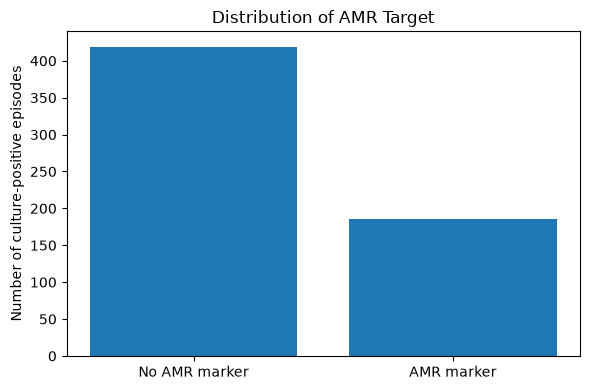

In [8]:
# Class distribution
class_counts = amr["any_resistant"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No AMR marker", "AMR marker"], class_counts.values)
ax.set_title("Distribution of AMR Target")
ax.set_ylabel("Number of culture-positive episodes")
plt.tight_layout()
plt.show()

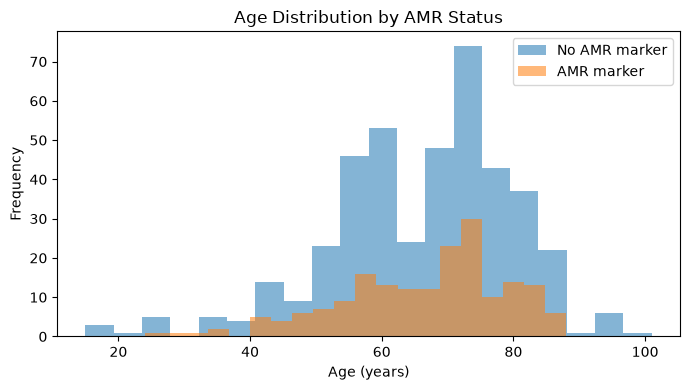

,count,median,mean,std
any_resistant,,,,
No AMR marker,419,69.0,66.167064,13.947124
AMR marker,185,69.0,66.351351,12.709583


In [9]:
# Age distribution by AMR status
fig, ax = plt.subplots(figsize=(7, 4))
for label, group in amr.groupby("any_resistant"):
    ax.hist(
        group["age_years"].dropna(),
        bins=20,
        alpha=0.55,
        label="AMR marker" if label == 1 else "No AMR marker"
    )
ax.set_title("Age Distribution by AMR Status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

display(
    amr.groupby("any_resistant")["age_years"]
    .agg(["count", "median", "mean", "std"])
    .rename(index={0: "No AMR marker", 1: "AMR marker"})
)

In [10]:
# Sex and AMR status
sex_table = pd.crosstab(amr["sex"], amr["any_resistant"], normalize="index") * 100
sex_table.columns = ["No AMR marker (%)", "AMR marker (%)"]
display(sex_table.round(1))

,No AMR marker (%),AMR marker (%)
sex,,
F,73.9,26.1
M,66.7,33.3


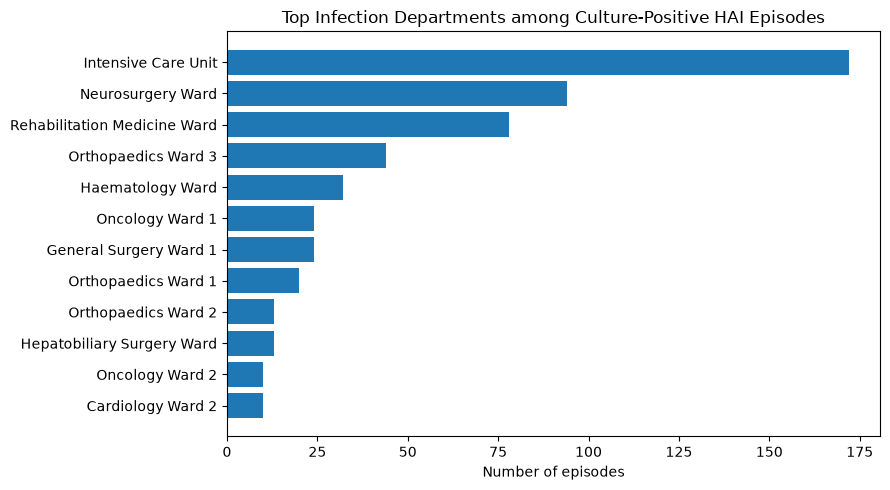

In [11]:
# Top infection departments
top_departments = amr["infection_dept"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_departments.index[::-1], top_departments.values[::-1])
ax.set_title("Top Infection Departments among Culture-Positive HAI Episodes")
ax.set_xlabel("Number of episodes")
plt.tight_layout()
plt.show()

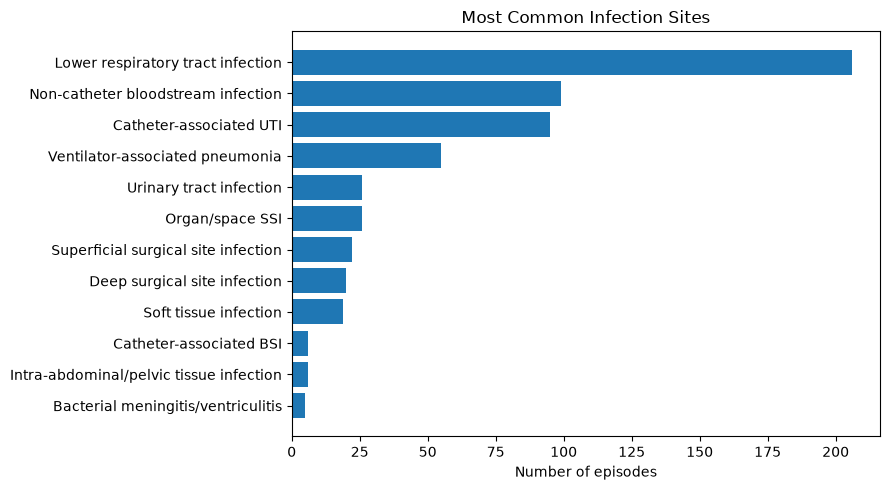

In [12]:
# Top infection sites
top_sites = amr["infection_site"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_sites.index[::-1], top_sites.values[::-1])
ax.set_title("Most Common Infection Sites")
ax.set_xlabel("Number of episodes")
plt.tight_layout()
plt.show()

### Pathogen distribution

We may inspect pathogen names descriptively, but we will **not** use the `pathogen` column as an ML feature because it contains the resistance-marker information used to define the target.

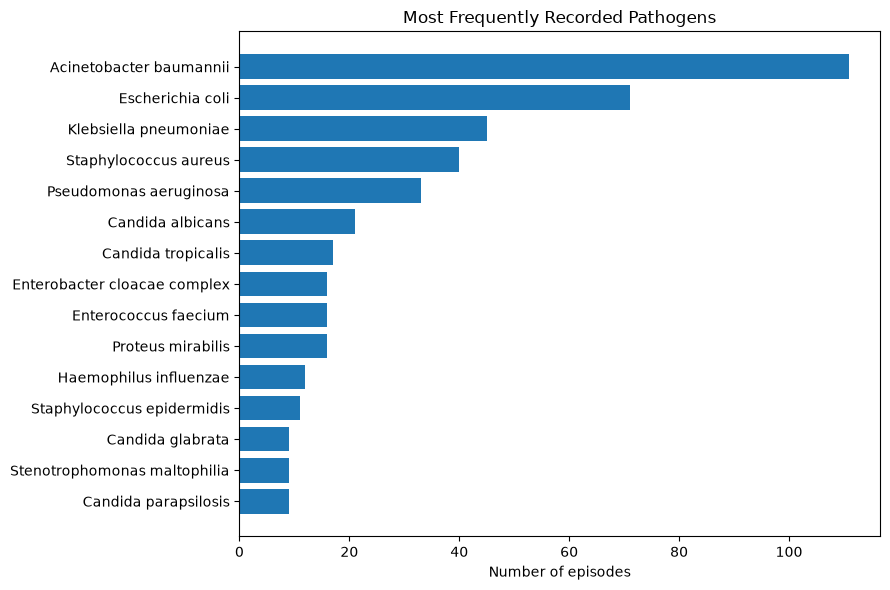

,count
pathogen_clean,
Acinetobacter baumannii,111
Escherichia coli,71
Klebsiella pneumoniae,45
Staphylococcus aureus,40
Pseudomonas aeruginosa,33
Candida albicans,21
Candida tropicalis,17
Enterobacter cloacae complex,16
Enterococcus faecium,16


In [13]:
def remove_amr_suffixes(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    for marker in AMR_MARKERS:
        text = text.replace(marker, "")
    return re.sub(r"\s+", " ", text).strip(" ,")

amr["pathogen_clean"] = amr["pathogen"].apply(remove_amr_suffixes)

top_pathogens = amr["pathogen_clean"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_pathogens.index[::-1], top_pathogens.values[::-1])
ax.set_title("Most Frequently Recorded Pathogens")
ax.set_xlabel("Number of episodes")
plt.tight_layout()
plt.show()

display(top_pathogens.to_frame("count"))

### Risk-factor prevalence

The dataset contains 19 binary `rf_*` indicators. We compare prevalence in episodes with and without an AMR marker.

,risk_factor,overall_pct,no_amr_pct,amr_pct,difference_pp
3,Bedridden,50.8,43.4,67.6,24.1
0,Urinary Catheter,41.9,38.2,50.3,12.1
1,Ventilator,29.0,18.1,53.5,35.4
14,Low Albumin,26.3,24.1,31.4,7.2
13,Malnutrition,21.5,18.4,28.6,10.3
11,Age Over 70,20.2,19.6,21.6,2.1
16,Stroke,18.4,14.1,28.1,14.0
2,Cvc,17.4,12.6,28.1,15.5
5,Hypertension,16.4,15.5,18.4,2.9
15,Anaemia,14.4,15.3,12.4,-2.8


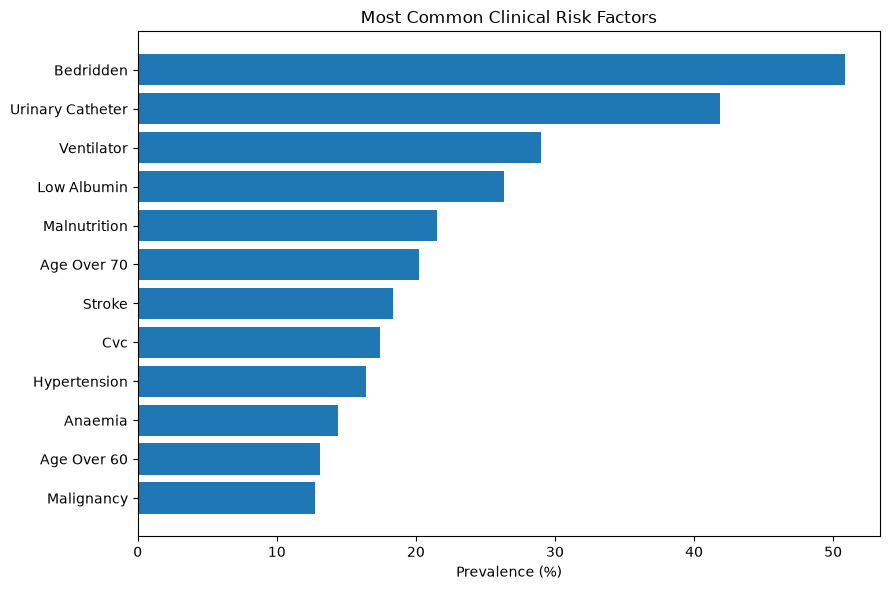

In [14]:
risk_summary = []

for col in rf_cols:
    overall = amr[col].mean()
    no_amr = amr.loc[amr["any_resistant"] == 0, col].mean()
    yes_amr = amr.loc[amr["any_resistant"] == 1, col].mean()

    risk_summary.append({
        "risk_factor": col.replace("rf_", "").replace("_", " ").title(),
        "overall_pct": overall * 100,
        "no_amr_pct": no_amr * 100,
        "amr_pct": yes_amr * 100,
        "difference_pp": (yes_amr - no_amr) * 100,
    })

risk_summary = pd.DataFrame(risk_summary).sort_values("overall_pct", ascending=False)
display(risk_summary.round(1))

plot_df = risk_summary.head(12).sort_values("overall_pct")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["risk_factor"], plot_df["overall_pct"])
ax.set_title("Most Common Clinical Risk Factors")
ax.set_xlabel("Prevalence (%)")
plt.tight_layout()
plt.show()

## 7. Define predictors carefully

We use a **leakage-conscious feature set** inspired by the public benchmark:

- `age_years`
- `sex`
- `days_to_infection`
- `infection_dept`
- all 19 `rf_*` risk-factor flags

### Variables deliberately excluded

- `pathogen` — contains the AMR marker used to create the target
- `length_of_stay_days` — includes information occurring after infection onset and may leak future information
- `outcome` — occurs after infection
- discharge-related variables — future information
- resistance marker itself — target leakage

In [15]:
NUMERIC_FEATURES = ["age_years", "days_to_infection"] + rf_cols
CATEGORICAL_FEATURES = ["sex", "infection_dept"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

TARGET = "any_resistant"

X = amr[FEATURES].copy()
y = amr[TARGET].copy()

print("Number of predictors before one-hot encoding:", X.shape[1])
print("Rows available:", len(X))
print("\nClass balance:")
display(y.value_counts(normalize=True).mul(100).round(1).to_frame("percent"))

Number of predictors before one-hot encoding: 23
Rows available: 604

Class balance:


,percent
any_resistant,
0,69.4
1,30.6


## 8. Train/test split

We use an **80/20 stratified split** so the AMR class proportion is approximately preserved.

The random state is fixed for reproducibility.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(1).to_frame("percent"))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(1).to_frame("percent"))

Training rows: 483
Test rows: 121

Training target distribution:


,percent
any_resistant,
0,69.4
1,30.6



Test target distribution:


,percent
any_resistant,
0,69.4
1,30.6


## 9. Build a reusable preprocessing pipeline

### Numeric variables
- median imputation
- standardisation

### Categorical variables
- most-frequent imputation
- one-hot encoding

Using a `Pipeline` ensures preprocessing is fitted **only on the training data**, reducing leakage.

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

print("Preprocessor ready.")

Preprocessor ready.


# 10. Train baseline and machine-learning models

Because the AMR-positive class is smaller, the real models use `class_weight="balanced"`.

The Dummy model establishes a baseline that a useful model should beat.

In [18]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

fitted_models = {}
test_results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
    })

test_results = (
    pd.DataFrame(test_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(test_results.round(3))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.736,0.726,0.553,0.703,0.619,0.816,0.656
1,Logistic Regression,0.711,0.724,0.519,0.757,0.615,0.762,0.587
2,Decision Tree,0.686,0.630,0.486,0.486,0.486,0.645,0.414
3,Dummy Baseline,0.694,0.500,0.000,0.000,0.000,0.500,0.306


## 11. Visualise model comparison

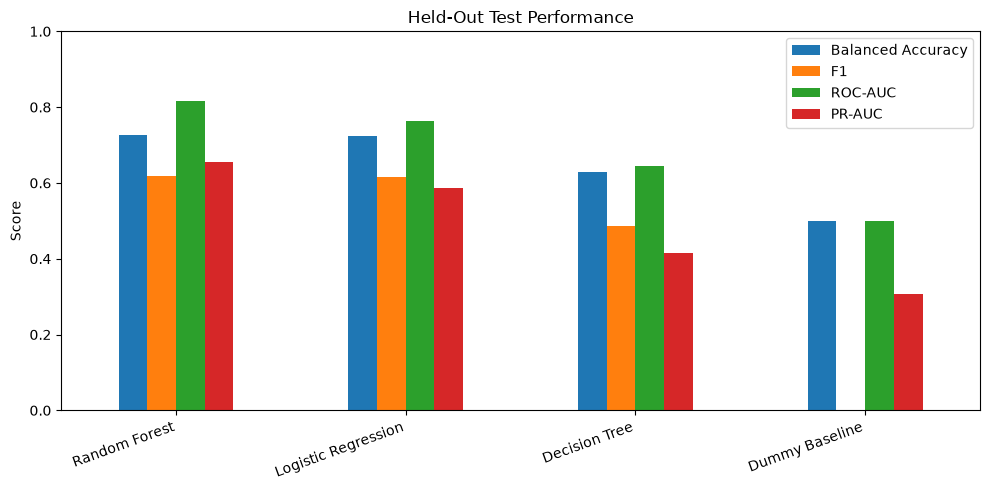

In [19]:
metric_cols = ["Balanced Accuracy", "F1", "ROC-AUC", "PR-AUC"]
plot_results = test_results.set_index("Model")[metric_cols]

ax = plot_results.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1)
ax.set_title("Held-Out Test Performance")
ax.set_ylabel("Score")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Classification reports

In [20]:
for name, model in fitted_models.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    y_pred = model.predict(X_test)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No AMR marker", "AMR marker"],
            digits=3,
            zero_division=0
        )
    )

Dummy Baseline
               precision    recall  f1-score   support

No AMR marker      0.694     1.000     0.820        84
   AMR marker      0.000     0.000     0.000        37

     accuracy                          0.694       121
    macro avg      0.347     0.500     0.410       121
 weighted avg      0.482     0.694     0.569       121

Logistic Regression
               precision    recall  f1-score   support

No AMR marker      0.866     0.690     0.768        84
   AMR marker      0.519     0.757     0.615        37

     accuracy                          0.711       121
    macro avg      0.692     0.724     0.692       121
 weighted avg      0.760     0.711     0.721       121

Decision Tree
               precision    recall  f1-score   support

No AMR marker      0.774     0.774     0.774        84
   AMR marker      0.486     0.486     0.486        37

     accuracy                          0.686       121
    macro avg      0.630     0.630     0.630       121
 weighte

## 13. Confusion matrices

For an AMR-screening style task, pay particular attention to **false negatives**: cases with an AMR marker that the model predicts as negative.

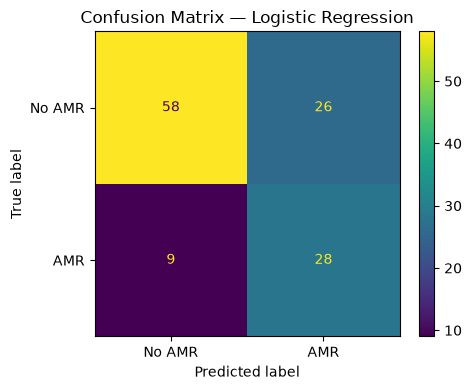

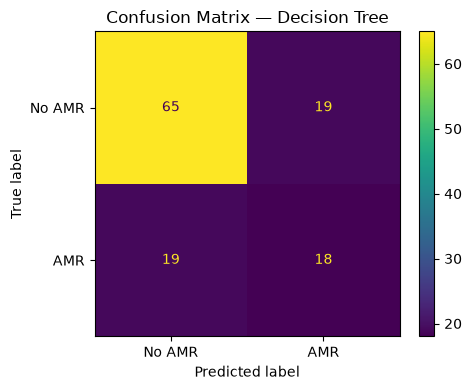

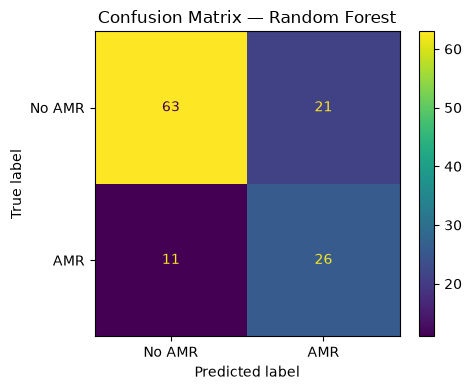

In [21]:
real_model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]

for name in real_model_names:
    model = fitted_models[name]
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["No AMR", "AMR"],
        ax=ax,
        values_format="d"
    )
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

## 14. ROC curves

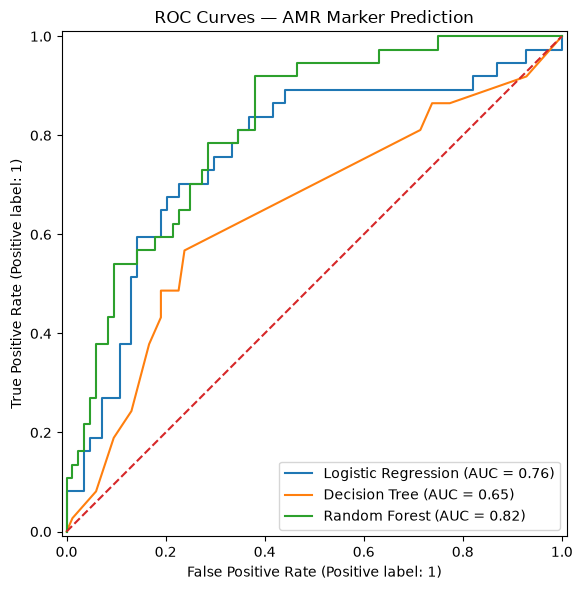

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

for name in real_model_names:
    RocCurveDisplay.from_estimator(
        fitted_models[name],
        X_test,
        y_test,
        ax=ax,
        name=name
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curves — AMR Marker Prediction")
plt.tight_layout()
plt.show()

## 15. Precision–Recall curves

Because the positive class is smaller, Precision–Recall curves are useful alongside ROC-AUC.

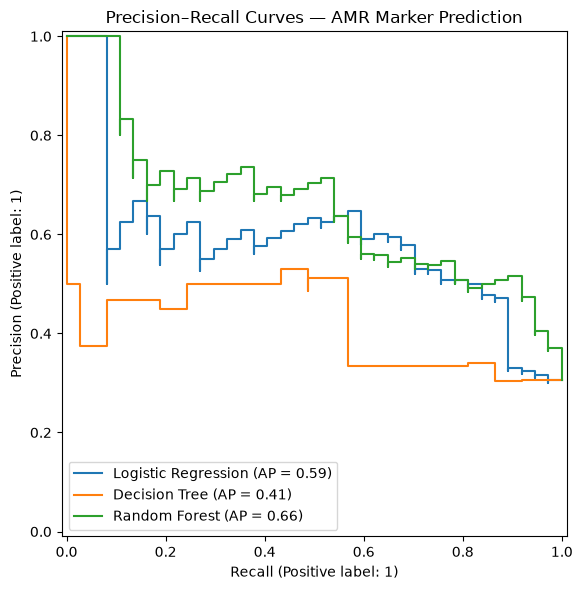

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

for name in real_model_names:
    PrecisionRecallDisplay.from_estimator(
        fitted_models[name],
        X_test,
        y_test,
        ax=ax,
        name=name
    )

ax.set_title("Precision–Recall Curves — AMR Marker Prediction")
plt.tight_layout()
plt.show()

# 16. Cross-validation

A single train/test split can be unstable in a modest-sized dataset. We therefore use **5-fold stratified cross-validation** on the training set.

We report:

- ROC-AUC
- F1
- balanced accuracy
- average precision

In [24]:
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name in real_model_names:
    scores = cross_validate(
        pipelines[name],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC SD": scores["test_roc_auc"].std(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "CV PR-AUC Mean": scores["test_average_precision"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV ROC-AUC Mean", ascending=False)
display(cv_results.round(3))

,Model,CV ROC-AUC Mean,CV ROC-AUC SD,CV F1 Mean,CV Balanced Accuracy Mean,CV PR-AUC Mean
0,Logistic Regression,0.750,0.047,0.575,0.687,0.559
2,Random Forest,0.740,0.072,0.561,0.677,0.562
1,Decision Tree,0.663,0.052,0.502,0.634,0.454


# 17. Tune the Random Forest

This is intentionally a **small grid** so it remains easy to run in Colab.

Grid search is performed only on the training set. The test set remains untouched until final evaluation.

In [25]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [2, 5],
    "model__max_features": ["sqrt", 0.7],
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(grid.best_score_, 3))
print("Best parameters:")
print(json.dumps(grid.best_params_, indent=2))

best_rf = grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best CV ROC-AUC: 0.748
Best parameters:
{
  "model__max_depth": null,
  "model__max_features": "sqrt",
  "model__min_samples_leaf": 2,
  "model__n_estimators": 200
}


## 18. Final tuned Random Forest evaluation

In [26]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1": f1_score(y_test, y_pred_best, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best),
    "PR-AUC": average_precision_score(y_test, y_prob_best),
}

final_metrics_df = pd.DataFrame(
    {"Metric": list(final_metrics.keys()), "Score": list(final_metrics.values())}
)

display(final_metrics_df.round(3))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["No AMR marker", "AMR marker"],
        digits=3,
        zero_division=0
    )
)

,Metric,Score
0,Accuracy,0.760
1,Balanced Accuracy,0.759
2,Precision,0.583
3,Recall,0.757
4,F1,0.659
5,ROC-AUC,0.822
6,PR-AUC,0.616



Classification report:
               precision    recall  f1-score   support

No AMR marker      0.877     0.762     0.815        84
   AMR marker      0.583     0.757     0.659        37

     accuracy                          0.760       121
    macro avg      0.730     0.759     0.737       121
 weighted avg      0.787     0.760     0.767       121



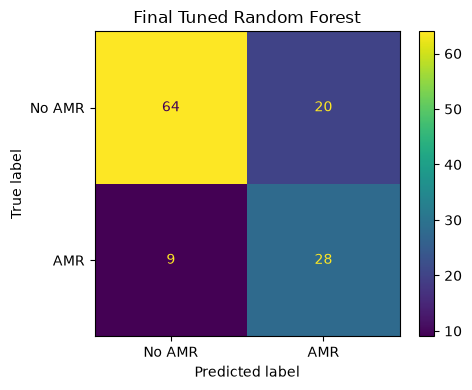

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    display_labels=["No AMR", "AMR"],
    ax=ax,
    values_format="d"
)
ax.set_title("Final Tuned Random Forest")
plt.tight_layout()
plt.show()

# 19. Feature importance using permutation importance

Permutation importance asks:

> If we randomly shuffle one original input variable, how much does ROC-AUC decrease?

This is easier to interpret than hundreds of one-hot encoded feature importances because it reports importance at the **original variable level**.

Feature importance is **associational**, not causal.

,Feature,Importance Mean,Importance SD
3,rf_ventilator,0.1098,0.0281
22,infection_dept,0.0888,0.0296
5,rf_bedridden,0.0212,0.0109
2,rf_urinary_catheter,0.0190,0.0073
0,age_years,0.0189,0.0117
21,sex,0.0182,0.0109
15,rf_malnutrition,0.0152,0.0082
14,rf_age_over_60,0.0104,0.0048
1,days_to_infection,0.0091,0.0121
6,rf_diabetes,0.0086,0.0059


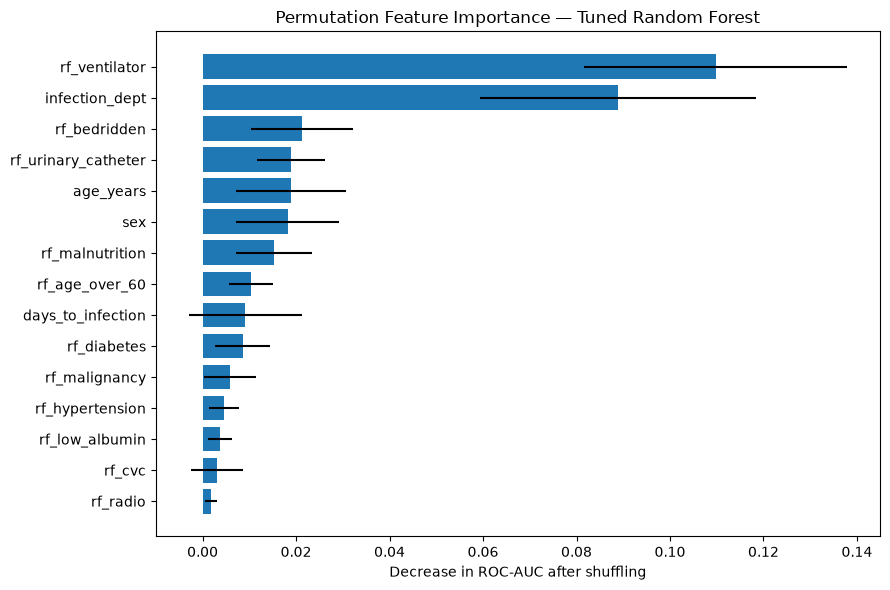

In [28]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance SD": perm.importances_std,
}).sort_values("Importance Mean", ascending=False)

display(importance_df.head(15).round(4))

top_imp = importance_df.head(15).sort_values("Importance Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_imp["Feature"], top_imp["Importance Mean"], xerr=top_imp["Importance SD"])
ax.set_title("Permutation Feature Importance — Tuned Random Forest")
ax.set_xlabel("Decrease in ROC-AUC after shuffling")
plt.tight_layout()
plt.show()

# 20. Optional: patient-level leakage sensitivity check

The dataset notes that the same de-identified `patient_id` can appear on more than one row if a patient had infections at multiple sites.

A random row-level split may therefore place episodes from the same patient in both train and test sets.

For a stronger portfolio analysis, the following cell performs a **group-aware holdout** so each patient belongs to only one split.

This section is optional because it is slightly more advanced.

In [29]:
from sklearn.model_selection import GroupShuffleSplit

groups = amr["patient_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, group_test_idx = next(gss.split(X, y, groups=groups))

X_train_g = X.iloc[train_idx]
X_test_g = X.iloc[group_test_idx]
y_train_g = y.iloc[train_idx]
y_test_g = y.iloc[group_test_idx]

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[group_test_idx])

print("Patient overlap:", len(train_patients.intersection(test_patients)))
print("Train rows:", len(X_train_g))
print("Test rows:", len(X_test_g))
print("Test AMR prevalence:", round(y_test_g.mean(), 3))

group_model = clone(best_rf)
group_model.fit(X_train_g, y_train_g)

group_prob = group_model.predict_proba(X_test_g)[:, 1]
group_pred = group_model.predict(X_test_g)

group_metrics = pd.DataFrame({
    "Metric": ["ROC-AUC", "F1", "Recall", "Precision", "Balanced Accuracy"],
    "Score": [
        roc_auc_score(y_test_g, group_prob),
        f1_score(y_test_g, group_pred, zero_division=0),
        recall_score(y_test_g, group_pred, zero_division=0),
        precision_score(y_test_g, group_pred, zero_division=0),
        balanced_accuracy_score(y_test_g, group_pred),
    ]
})

display(group_metrics.round(3))

Patient overlap: 0
Train rows: 485
Test rows: 119
Test AMR prevalence: 0.328


,Metric,Score
0,ROC-AUC,0.752
1,F1,0.617
2,Recall,0.641
3,Precision,0.595
4,Balanced Accuracy,0.714


# 21. Save project outputs

The next cell saves:

- model comparison table
- cross-validation table
- final tuned-model metrics
- feature importance table
- analysis-ready AMR subset
- trained Random Forest pipeline

The saved model includes preprocessing, so it can later be loaded with `joblib.load()`.

In [30]:
test_results.to_csv(OUTPUT_DIR / "model_test_results.csv", index=False)
cv_results.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)
final_metrics_df.to_csv(OUTPUT_DIR / "final_model_metrics.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

analysis_export_cols = [
    "patient_id", "sex", "age_years", "days_to_infection",
    "infection_dept", "infection_site", "pathogen_clean",
    "any_resistant"
] + rf_cols

amr[analysis_export_cols].to_csv(
    OUTPUT_DIR / "amr_analysis_dataset.csv",
    index=False
)

joblib.dump(best_rf, OUTPUT_DIR / "best_random_forest_pipeline.joblib")

print("Saved files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)

Saved files:
 - amr_project_outputs\amr_analysis_dataset.csv
 - amr_project_outputs\best_random_forest_pipeline.joblib
 - amr_project_outputs\cross_validation_results.csv
 - amr_project_outputs\feature_importance.csv
 - amr_project_outputs\final_model_metrics.csv
 - amr_project_outputs\model_test_results.csv


## 22. Create a ZIP file for easy download

In [31]:
import shutil

archive_path = shutil.make_archive(
    "rabiatu_amr_project_outputs",
    "zip",
    OUTPUT_DIR
)

print("Created:", archive_path)

# In Google Colab, uncomment these two lines to download:
# from google.colab import files
# files.download(archive_path)

Created: C:\Users\USER\Documents\Rabiatu\rabiatu_amr_project_outputs.zip


# 23. Automatically summarise the final model

This creates a short factual summary from the metrics generated by the notebook.

In [32]:
best_model_name = test_results.iloc[0]["Model"]
best_test_auc = test_results.iloc[0]["ROC-AUC"]

print("PROJECT SUMMARY")
print("-" * 60)
print(f"Culture-positive episodes analysed: {len(amr)}")
print(f"Episodes with a recorded AMR marker: {int(amr['any_resistant'].sum())}")
print(f"AMR-marker prevalence: {amr['any_resistant'].mean() * 100:.1f}%")
print(f"Best untuned model on the held-out test set by ROC-AUC: {best_model_name}")
print(f"Best untuned test ROC-AUC: {best_test_auc:.3f}")
print(f"Tuned Random Forest test ROC-AUC: {final_metrics['ROC-AUC']:.3f}")
print(f"Tuned Random Forest recall: {final_metrics['Recall']:.3f}")
print(f"Tuned Random Forest F1: {final_metrics['F1']:.3f}")

PROJECT SUMMARY
------------------------------------------------------------
Culture-positive episodes analysed: 604
Episodes with a recorded AMR marker: 185
AMR-marker prevalence: 30.6%
Best untuned model on the held-out test set by ROC-AUC: Random Forest
Best untuned test ROC-AUC: 0.816
Tuned Random Forest test ROC-AUC: 0.822
Tuned Random Forest recall: 0.757
Tuned Random Forest F1: 0.659


# 24. How to interpret the results

When Rabiatu presents this project, she should explain the work in this order:

### Problem
Antimicrobial resistance makes bacterial infections harder to treat and creates major challenges for infection prevention and surveillance.

### Data
A public, de-identified dataset of healthcare-associated infection episodes containing demographics, infection timing, ward information, microbiology records and clinical risk factors.

### Target
Whether a culture-positive episode contains one of the recorded AMR markers: CRAB, CRKP, CRPA, CRE or MRSA.

### Method
1. Clean and inspect the data.
2. Construct the AMR target.
3. Perform microbiology-focused EDA.
4. Prevent obvious target/future leakage.
5. Split the data into training and test sets.
6. Preprocess numeric and categorical variables through a pipeline.
7. Compare Logistic Regression, Decision Tree and Random Forest against a dummy baseline.
8. Evaluate using ROC-AUC, PR-AUC, recall, precision, F1 and balanced accuracy.
9. Tune the Random Forest using cross-validation.
10. Examine permutation feature importance.

### What she should NOT claim
Do **not** say:
- “The model diagnoses antibiotic resistance.”
- “The model should be used in hospitals.”
- “The important features cause resistance.”

Instead say:
> “This is an educational and research-oriented machine-learning analysis of recorded AMR markers in a public HAI surveillance dataset.”

# 28. Reproducibility information

**Dataset:** FAIR-compliant healthcare-associated infection surveillance dataset  
**Zenodo DOI:** https://doi.org/10.5281/zenodo.20725167  
**Public repository:** https://github.com/Griseldaoipl/hai-fair-pipeline  
**Data licence:** CC BY 4.0

If this project is shared publicly, retain the dataset citation and attribution.

---

## Next possible extension

After completing this project, a stronger microbiology-focused follow-up would be to build an **antibiotic-specific AMR model** using a dataset with organism–drug susceptibility labels (e.g., susceptible/resistant to ciprofloxacin or meropenem). That would answer a narrower and more clinically interpretable question.